In [ ]:
# ── Setup ─────────────────────────────────────────────────────
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

import os, cv2, torch, numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
from google.colab import files
from IPython.display import display, Image as IPImage
from pathlib import Path

os.environ["TORCH_COMPILE_DISABLE"] = "1"
os.makedirs("outputs", exist_ok=True)

SAVE_DIR   = "/content/drive/MyDrive/brain_tumour_project/checkpoints"
DEVICE_OBJ = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"GPU: {torch.cuda.get_device_name(0)}")

# Patch fast file
with open("brain_tumor_fast.py", "r") as f:
    code = f.read()
code = code.replace("self.model = torch.compile(self.model)", "pass")
code = code.replace("persistent_workers=(workers>0)", "persistent_workers=False")
code = code.replace("prefetch_factor=2 if workers > 0 else None", "prefetch_factor=None")
with open("brain_tumor_fast.py", "w") as f:
    f.write(code)

# Verify all 4 models are saved
print("\nChecking all models:")
for fname in ["fast_seg_best (1).pth","cls_best.pth",
              "survival_best.pth","growth_best.pth"]:
    fp = Path(SAVE_DIR) / fname
    if fp.exists():
        print(f"  ✅ {fname}  ({fp.stat().st_size/1024/1024:.1f} MB)")
    else:
        print(f"  ❌ {fname} NOT FOUND")

Mounted at /content/drive
GPU: Tesla T4

Checking all models:
  ✅ fast_seg_best (1).pth  (13.1 MB)
  ✅ cls_best.pth  (3.0 MB)
  ✅ survival_best.pth  (0.1 MB)
  ✅ growth_best.pth  (0.1 MB)


In [ ]:
import torch, torch.nn as nn, os
os.environ["TORCH_COMPILE_DISABLE"] = "1"

SAVE_DIR   = "/content/drive/MyDrive/brain_tumour_project/checkpoints"
DEVICE_OBJ = torch.device("cuda" if torch.cuda.is_available() else "cpu")

from brain_tumor_fast import FastUNet3Plus, FastTumourClassifier

seg_model = FastUNet3Plus(in_ch=4, seg_classes=4,
                           filters=[64,128,256,512,1024]).to(DEVICE_OBJ)
seg_model.load_state_dict(torch.load(
    f"{SAVE_DIR}/fast_seg_best (1).pth", map_location=DEVICE_OBJ))
seg_model.eval()
print("Segmentor loaded")

cls_model = FastTumourClassifier(num_classes=4).to(DEVICE_OBJ)
cls_model.load_state_dict(torch.load(
    f"{SAVE_DIR}/cls_best.pth", map_location=DEVICE_OBJ))
cls_model.eval()
print("Classifier loaded")

class SurvivalPredictor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(30,128), nn.LayerNorm(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128,64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64,32),  nn.ReLU(), nn.Linear(32,1))
    def forward(self,x): return self.net(x).squeeze(-1)

surv_model = SurvivalPredictor().to(DEVICE_OBJ)
surv_model.load_state_dict(torch.load(
    f"{SAVE_DIR}/survival_best.pth", map_location=DEVICE_OBJ))
surv_model.eval()
print("Survival loaded")

class GrowthPredictor(nn.Module):
    def __init__(self):
        super().__init__()
        self.shared    = nn.Sequential(
            nn.Linear(27,128), nn.ReLU(), nn.Dropout(0.25),
            nn.Linear(128,64), nn.ReLU(), nn.Dropout(0.25),
            nn.Linear(64,32),  nn.ReLU())
        self.mean_head = nn.Linear(32,3)
        self.logv_head = nn.Linear(32,3)
    def forward(self,x):
        h = self.shared(x)
        return self.mean_head(h), self.logv_head(h)

grow_model = GrowthPredictor().to(DEVICE_OBJ)
grow_model.load_state_dict(torch.load(
    f"{SAVE_DIR}/growth_best.pth", map_location=DEVICE_OBJ))
grow_model.eval()
print("Growth loaded")

print("\nAll 4 models ready — now run Cell 4")

Segmentor loaded
Classifier loaded
Survival loaded
Growth loaded

All 4 models ready — now run Cell 4


orchestral pipeline


In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import cv2
import os
import json
import time
from pathlib import Path
from IPython.display import display, Image as IPImage
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap

class BrainTumourOrchestrator:
    """
    Central communication layer between all 4 trained models.
    Segmentor gates everything downstream.
    No tumour = nothing else runs.
    Conflict between segmentor and classifier = segmentor wins.
    Low confidence = UNCERTAIN flag, no forced type.
    """

    CONFIDENCE_THRESHOLD = 0.55   # below this = uncertain
    TUMOUR_PIXEL_MIN     = 50     # below this = no tumour
    CGM_THRESHOLD        = 0.35   # below this = no tumour

    def __init__(self, seg_model, cls_model, surv_model,
                 grow_model, device, seg_thresh=0.45):
        self.seg   = seg_model
        self.cls   = cls_model
        self.surv  = surv_model
        self.grow  = grow_model
        self.dev   = torch.device(device)
        self.thresh= seg_thresh

        from brain_tumor_complete import RadiomicsExtractor
        self.radiomics = RadiomicsExtractor()

    # ── STEP 1: Segmentation (primary gate) ───────────────────
    def _run_segmentor(self, tensor):
        from brain_tumor_fast import tta_predict_seg
        prob_map = tta_predict_seg(self.seg, tensor)[0].cpu().numpy()
        tumour_p = prob_map[1:].sum(0)
        mask     = (tumour_p > self.thresh).astype(np.uint8)
        with torch.no_grad():
            _, cgm_l = self.seg(tensor)
        cgm_p = float(torch.softmax(cgm_l, dim=1)[0,1].item())
        pred_seg = prob_map.argmax(0)
        return prob_map, mask, cgm_p, pred_seg

    # ── STEP 2: Classification (only if tumour found) ─────────
    def _run_classifier(self, mri_disp):
        img_224   = cv2.resize(
            (mri_disp*255).astype(np.uint8),(224,224)
        ).astype(np.float32)/255.0
        cls_input = torch.from_numpy(
            np.stack([img_224]*3,axis=0)
        ).float().unsqueeze(0).to(self.dev)
        with torch.no_grad():
            cls_out   = self.cls(cls_input)
            cls_probs = torch.softmax(cls_out,dim=1)[0].cpu().numpy()
        return cls_probs

    # ── STEP 3: Survival (only if tumour + valid type) ────────
    def _run_survival(self, rad_np, pred_class, mask, cgm_p, dom):
        t_oh = np.zeros(4,np.float32); t_oh[min(pred_class,3)]=1
        r_oh = np.zeros(4,np.float32); r_oh[min(dom,3)]=1
        inp  = np.concatenate([
            rad_np[:20], t_oh,
            [float(mask.sum())/10000], [cgm_p], r_oh
        ])
        t = torch.from_numpy(inp).float().unsqueeze(0).to(self.dev)
        with torch.no_grad():
            days = max(30.0, float(self.surv(t).item())*1000)
        return days

    # ── STEP 4: Growth (only if tumour + valid type) ──────────
    def _run_growth(self, mask, pred_class, pred_seg, rad_np):
        vol  = float(mask.sum())/10000.0
        tot  = float(mask.sum())+1e-8
        et_r = float((pred_seg==3).sum())/tot
        ed_r = float((pred_seg==2).sum())/tot
        t_oh = np.zeros(4,np.float32); t_oh[min(pred_class,3)]=1
        inp  = np.concatenate([[vol],t_oh,[et_r],[ed_r],rad_np[:20]])
        t    = torch.from_numpy(inp.astype(np.float32)
                                ).float().unsqueeze(0).to(self.dev)
        with torch.no_grad():
            g_mean, g_logv = self.grow(t)
        means = g_mean[0].cpu().numpy()
        stds  = torch.exp(g_logv[0]/2).cpu().numpy()
        current = int(mask.sum())
        forecast = []
        for i,d in enumerate([30,90,180]):
            pv  = max(0, float(means[i])*10000)
            sv  = float(stds[i])*10000
            pct = (pv-current)/max(current,1)*100
            forecast.append({
                "days":d, "vox":int(pv), "std":int(sv),
                "pct":pct,
                "trend":"GROWING" if pct>10
                         else "STABLE" if pct>-10
                         else "SHRINKING"
            })
        return forecast

    # ── STEP 5: XAI (only if tumour found) ───────────────────
    def _run_xai(self, tensor, mri_disp, mask):
        # Grad-CAM
        acts, grads = [None], [None]
        tgt = self.seg.enc5.c2.dw
        h1  = tgt.register_forward_hook(
            lambda m,i,o: acts.__setitem__(0, o.detach()))
        h2  = tgt.register_full_backward_hook(
            lambda m,gi,go: grads.__setitem__(0, go[0].detach()))
        try:
            x2  = tensor.detach().clone().requires_grad_(True)
            out = self.seg(x2)
            seg = out[0] if isinstance(out,tuple) else out
            self.seg.zero_grad()
            seg[0,1].mean().backward()
            if acts[0] is not None and grads[0] is not None:
                w   = grads[0].mean(dim=(2,3),keepdim=True)
                cam = F.relu((w*acts[0]).sum(1,keepdim=True))
                cam = F.interpolate(cam,(128,128),
                                    mode="bilinear",align_corners=False)
                cam = cam.squeeze().detach().cpu().numpy().astype(np.float32)
                lo,hi = cam.min(),cam.max()
                cam   = (cam-lo)/(hi-lo+1e-8)
            else:
                cam = np.zeros((128,128),np.float32)
        except:
            cam = np.zeros((128,128),np.float32)
        finally:
            h1.remove(); h2.remove()

        # Saliency
        try:
            x3  = tensor.detach().clone().requires_grad_(True)
            out = self.seg(x3)
            seg = out[0] if isinstance(out,tuple) else out
            self.seg.zero_grad()
            seg[0,1].mean().backward()
            sal = x3.grad.abs().mean(dim=1).squeeze()
            sal = sal.detach().cpu().numpy().astype(np.float32)
            lo,hi = sal.min(),sal.max()
            sal   = (sal-lo)/(hi-lo+1e-8)
        except:
            sal = np.zeros((128,128),np.float32)

        # Ensemble
        ens   = cam*0.6 + sal*0.4
        lo,hi = ens.min(),ens.max()
        ens   = (ens-lo)/(hi-lo+1e-8)

        # Apply mask — no tumour = black heatmap
        cam_masked = cam * mask.astype(np.float32)
        ens_masked = ens * mask.astype(np.float32)

        return cam_masked, sal, ens_masked

    # ── MAIN PREDICT ──────────────────────────────────────────
    def predict(self, mri_tensor, patient_id="PATIENT_001",
                patient_name="Anonymous", patient_age="N/A",
                patient_gender="N/A", save_dir="outputs"):

        os.makedirs(save_dir, exist_ok=True)
        TUMOUR_TYPES = {0:"No Tumour",1:"Glioma",
                        2:"Meningioma",3:"Pituitary"}
        SUB_REGION   = {0:"Background",1:"Necrotic Core (NCR)",
                        2:"Oedema (ED)",3:"Enhancing Tumour (ET)"}

        mri_tensor = mri_tensor.to(self.dev)
        if mri_tensor.dim()==3:
            mri_tensor = mri_tensor.unsqueeze(0)

        ch      = 1 if mri_tensor.shape[1]>=2 else 0
        disp    = mri_tensor[0,ch].cpu().numpy()
        lo,hi   = disp.min(),disp.max()
        mri_disp= (disp-lo)/(hi-lo+1e-8)

        # ── GATE 1: Segmentation ──────────────────────────────
        print("[1/6] Running segmentor...")
        prob_map, mask, cgm_p, pred_seg = self._run_segmentor(mri_tensor)

        tumour_pixels = int(mask.sum())
        has_tumour    = (tumour_pixels >= self.TUMOUR_PIXEL_MIN
                         and cgm_p >= self.CGM_THRESHOLD)

        print(f"      Tumour pixels : {tumour_pixels}")
        print(f"      CGM score     : {cgm_p:.3f}")
        print(f"      Decision      : {'TUMOUR DETECTED' if has_tumour else 'NO TUMOUR'}")

        # Dominant region
        dom = 0
        for lbl in [3,1,2]:
            if (pred_seg==lbl).any(): dom=lbl; break

        # Radiomics always run (cheap)
        rad_t  = self.radiomics.batch_extract(
            mri_tensor, torch.from_numpy(mask).unsqueeze(0))
        rad_np = rad_t[0].numpy()

        # ── GATE 2: Classification (only if tumour) ───────────
        if has_tumour:
            print("[2/6] Running classifier...")
            cls_probs  = self._run_classifier(mri_disp)
            raw_pred   = int(cls_probs.argmax())
            raw_conf   = float(cls_probs[raw_pred])

            # Conflict resolution: segmentor wins
            if raw_pred == 0:
                # Classifier says no tumour but segmentor disagrees
                # Pick best tumour class
                pred_class = int(cls_probs[1:].argmax()) + 1
                confidence = float(cls_probs[pred_class])
                conflict   = True
                print(f"      Conflict resolved: segmentor wins")
            else:
                pred_class = raw_pred
                confidence = raw_conf
                conflict   = False

            # Uncertainty check
            is_uncertain = confidence < self.CONFIDENCE_THRESHOLD
            if is_uncertain:
                type_name = f"UNCERTAIN ({TUMOUR_TYPES[pred_class]} suspected)"
                print(f"      Low confidence ({confidence:.2f}) — flagged uncertain")
            else:
                type_name = TUMOUR_TYPES[pred_class]

            print(f"      Type          : {type_name}")
            print(f"      Confidence    : {confidence*100:.1f}%")
        else:
            # No tumour — skip classifier
            print("[2/6] Classifier skipped — no tumour detected")
            cls_probs  = np.array([1.0,0.0,0.0,0.0],np.float32)
            pred_class = 0
            confidence = 1.0
            type_name  = "No Tumour"
            is_uncertain = False
            conflict   = False

        # ── GATE 3: Survival (only if valid tumour type) ──────
        if has_tumour and not is_uncertain:
            print("[3/6] Running survival predictor...")
            surv_days = self._run_survival(
                rad_np, pred_class, mask, cgm_p, dom)
            if surv_days < 90:       surv_interp = "POOR prognosis"
            elif surv_days < 365:    surv_interp = "MODERATE prognosis"
            elif surv_days < 365*5:  surv_interp = "GOOD prognosis"
            else:                    surv_interp = "EXCELLENT prognosis"
            print(f"      Survival      : {surv_days:.0f} days — {surv_interp}")
        elif has_tumour and is_uncertain:
            print("[3/6] Survival skipped — uncertain classification")
            surv_days   = None
            surv_interp = "Not available — uncertain classification"
        else:
            print("[3/6] Survival skipped — no tumour")
            surv_days   = None
            surv_interp = "Not applicable — no tumour detected"

        # ── GATE 4: Growth (only if valid tumour type) ────────
        if has_tumour and not is_uncertain:
            print("[4/6] Running growth predictor...")
            forecast = self._run_growth(
                mask, pred_class, pred_seg, rad_np)
            for f in forecast:
                print(f"      +{f['days']:3d}d: {f['vox']:,} voxels "
                      f"({f['pct']:+.1f}%) — {f['trend']}")
        else:
            print("[4/6] Growth skipped —",
                  "no tumour" if not has_tumour else "uncertain classification")
            forecast = []

        # ── GATE 5: XAI (only if tumour) ──────────────────────
        if has_tumour:
            print("[5/6] Running XAI explanations...")
            cam, sal, ens = self._run_xai(mri_tensor, mri_disp, mask)
        else:
            print("[5/6] XAI skipped — no tumour (blank heatmaps)")
            cam = np.zeros((128,128),np.float32)
            sal = np.zeros((128,128),np.float32)
            ens = np.zeros((128,128),np.float32)

        # ── GATE 6: Build report ───────────────────────────────
        print("[6/6] Building report...")

        # Bounding box
        contours,_ = cv2.findContours(
            mask,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
        bbox = cv2.boundingRect(max(contours,key=cv2.contourArea)) \
               if contours else None

        # Clinical recommendation
        if not has_tumour:
            recommendation = ("ROUTINE — No significant tumour detected. "
                              "Standard follow-up advised.")
        elif is_uncertain:
            recommendation = (f"REVIEW — Uncertain prediction "
                              f"({TUMOUR_TYPES[pred_class]} suspected, "
                              f"confidence {confidence*100:.0f}%). "
                              f"Expert radiologist review required.")
        elif confidence > 0.80:
            recommendation = (f"URGENT — High confidence {type_name} "
                              f"({confidence*100:.0f}%). "
                              f"Immediate radiologist review recommended.")
        else:
            recommendation = (f"REVIEW — {type_name} detected "
                              f"({confidence*100:.0f}% confidence). "
                              f"Radiologist confirmation needed.")

        result = {
            # Core
            "has_tumour":      has_tumour,
            "cgm_confidence":  cgm_p,
            "tumour_pixels":   tumour_pixels,
            "bbox":            bbox,
            "mask":            mask,
            "pred_seg":        pred_seg,
            "seg_prob":        prob_map,
            "mri_display":     mri_disp,
            "radiomics":       rad_np,
            # Classification
            "tumour_type":     pred_class,
            "type_name":       type_name,
            "type_probs":      cls_probs,
            "confidence":      confidence,
            "is_uncertain":    is_uncertain,
            "conflict":        conflict,
            # XAI
            "cam":             cam,
            "saliency":        sal,
            "ensemble_xai":    ens,
            # Downstream (None if no tumour)
            "survival_days":   surv_days,
            "survival_interp": surv_interp,
            "growth_forecast": forecast,
            # Summary
            "dominant_region": SUB_REGION[dom],
            "recommendation":  recommendation,
            # Meta
            "patient_id":      patient_id,
            "patient_name":    patient_name,
            "patient_age":     patient_age,
            "patient_gender":  patient_gender,
            "timestamp":       time.strftime("%Y-%m-%d %H:%M:%S"),
        }

        # Save outputs
        self._save_diagnostic_image(result, save_dir)
        self._save_xai_image(result, save_dir)
        self._save_json(result, save_dir)

        print(f"\n{'='*55}")
        print(f"  FINAL RESULT: {('TUMOUR DETECTED' if has_tumour else 'NO TUMOUR')}")
        print(f"  Type         : {type_name}")
        print(f"  Confidence   : {confidence*100:.1f}%")
        if surv_days:
            print(f"  Survival     : {surv_days:.0f} days — {surv_interp}")
        if forecast:
            print(f"  Growth +30d  : {forecast[0]['trend']}")
        print(f"  Recommend    : {recommendation}")
        print(f"{'='*55}")

        return result

    def _save_diagnostic_image(self, r, save_dir):
        TUMOUR_TYPES = {0:"No Tumour",1:"Glioma",
                        2:"Meningioma",3:"Pituitary"}
        fig = plt.figure(figsize=(22,14), facecolor="#080c12")
        gs  = gridspec.GridSpec(2,3,figure=fig,
                                hspace=0.35,wspace=0.25)

        def sax(ax,title,col="white"):
            ax.set_facecolor("#0d1117"); ax.axis("off")
            ax.set_title(title,color=col,fontsize=11,pad=8)

        # Panel 1 — MRI
        ax1 = fig.add_subplot(gs[0,0])
        sax(ax1,"Input MRI")
        ax1.imshow(r["mri_display"],cmap="gray")

        # Panel 2 — Segmentation
        ax2 = fig.add_subplot(gs[0,1])
        seg_col = "#e63946" if r["has_tumour"] else "#2a9d8f"
        sax(ax2,f"Segmentation — {'TUMOUR' if r['has_tumour'] else 'NO TUMOUR'}",
            col=seg_col)
        ax2.imshow(r["mri_display"],cmap="gray")
        if r["has_tumour"]:
            cmap4=ListedColormap(["#00000000","#e6394699","#f4a26199","#2a9d8f99"])
            ax2.imshow(cmap4(r["pred_seg"]/3.0),alpha=0.75)
            patches=[mpatches.Patch(color=c,label=l) for c,l in zip(
                ["#e63946","#f4a261","#2a9d8f"],
                ["Necrotic","Oedema","Enhancing"])]
            ax2.legend(handles=patches,loc="lower right",
                       fontsize=7,facecolor="#111",labelcolor="white")

        # Panel 3 — XAI heatmap
        ax3 = fig.add_subplot(gs[0,2])
        sax(ax3,"Grad-CAM XAI" if r["has_tumour"] else "XAI (No Tumour)")
        ax3.imshow(r["mri_display"],cmap="gray",alpha=0.6)
        if r["has_tumour"]:
            ax3.imshow(r["cam"],cmap="hot",alpha=0.7,vmin=0,vmax=1)

        # Panel 4 — Classification
        ax4 = fig.add_subplot(gs[1,0])
        ax4.set_facecolor("#0d1117")
        ax4.tick_params(colors="white",labelsize=8)
        for sp in ax4.spines.values(): sp.set_edgecolor("#333")
        ax4.set_title("Classification",color="white",fontsize=11,pad=8)
        colors=["#2a9d8f","#e63946","#f4a261","#457b9d"]
        bars=ax4.barh([TUMOUR_TYPES[i] for i in range(4)],
                      r["type_probs"],color=colors,alpha=0.85)
        bars[r["tumour_type"]].set_edgecolor("white")
        bars[r["tumour_type"]].set_linewidth(2.5)
        for i,p in enumerate(r["type_probs"]):
            ax4.text(p+0.01,i,f"{p*100:.1f}%",
                     va="center",color="white",fontsize=8)
        ax4.set_xlim(0,1.15)
        ax4.set_xlabel("Probability",color="#aaa",fontsize=8)

        # Panel 5 — Growth or blank
        ax5 = fig.add_subplot(gs[1,1])
        ax5.set_facecolor("#0d1117")
        ax5.tick_params(colors="white",labelsize=8)
        for sp in ax5.spines.values(): sp.set_edgecolor("#333")
        ax5.set_title("Growth Forecast",color="white",fontsize=11,pad=8)
        if r["growth_forecast"]:
            xs=[0]+[f["days"] for f in r["growth_forecast"]]
            ys=[r["tumour_pixels"]]+[f["vox"] for f in r["growth_forecast"]]
            ax5.plot(xs,ys,"o-",color="#4fc3f7",linewidth=2.5,markersize=7)
            ax5.axhline(r["tumour_pixels"],color="#f48fb1",
                        linestyle="--",alpha=0.7,label="Current")
            for f in r["growth_forecast"]:
                col=("#e63946" if f["trend"]=="GROWING"
                     else "#2a9d8f" if f["trend"]=="SHRINKING"
                     else "#f4a261")
                ax5.annotate(f["trend"],xy=(f["days"],f["vox"]),
                             color=col,fontsize=7,ha="center",va="bottom")
            ax5.set_xlabel("Days",color="#aaa",fontsize=8)
            ax5.set_ylabel("Voxels",color="#aaa",fontsize=8)
            ax5.legend(labelcolor="white",facecolor="#111",fontsize=7)
        else:
            ax5.text(0.5,0.5,"Not applicable\n(No tumour detected)",
                     transform=ax5.transAxes,ha="center",va="center",
                     color="#888",fontsize=11)

        # Panel 6 — Summary
        ax6 = fig.add_subplot(gs[1,2])
        ax6.set_facecolor("#0d1117"); ax6.axis("off")
        ax6.set_title("Clinical Summary",color="white",fontsize=11,pad=8)

        bdr = "#e63946" if r["has_tumour"] else "#2a9d8f"
        fc  = "#3d0000" if r["has_tumour"] else "#002a28"
        ax6.add_patch(mpatches.FancyBboxPatch(
            (0.03,0.82),0.94,0.13,transform=ax6.transAxes,
            boxstyle="round,pad=0.02",fc=fc,ec=bdr,lw=2))
        ax6.text(0.5,0.885,
                 "TUMOUR DETECTED" if r["has_tumour"] else "NO TUMOUR",
                 transform=ax6.transAxes,ha="center",va="center",
                 color=bdr,fontsize=13,weight="bold")

        info=[
            ("Type",      r["type_name"],             "#4fc3f7"),
            ("Confidence",f"{r['confidence']*100:.1f}%","#a5d6a7"),
            ("CGM Score", f"{r['cgm_confidence']:.3f}","#ce93d8"),
            ("Region",    r["dominant_region"],         "#f4a261"),
        ]
        if r["survival_days"]:
            info.append(("Survival",
                          f"{r['survival_days']:.0f}d — {r['survival_interp']}",
                          "#ffcc80"))
        if r["growth_forecast"]:
            info.append(("+30 days",r["growth_forecast"][0]["trend"],"#4fc3f7"))
            info.append(("+90 days",r["growth_forecast"][1]["trend"],"#4fc3f7"))
        if r["is_uncertain"]:
            info.append(("FLAG","UNCERTAIN — Expert review needed","#ff7043"))
        if r["conflict"]:
            info.append(("Note","Seg/Cls conflict resolved","#ffb74d"))

        y=0.76
        for key,val,col in info:
            ax6.text(0.05,y,f"{key}:",transform=ax6.transAxes,
                     color="#888",fontsize=8)
            ax6.text(0.38,y,str(val),transform=ax6.transAxes,
                     color=col,fontsize=8,weight="bold")
            y-=0.09

        # Recommendation box
        ax6.text(0.05,y-0.02,"Recommendation:",
                 transform=ax6.transAxes,color="#888",fontsize=7)
        ax6.text(0.05,y-0.10,r["recommendation"],
                 transform=ax6.transAxes,color="white",fontsize=6.5,
                 wrap=True,verticalalignment="top")

        status = "TUMOUR DETECTED" if r["has_tumour"] else "NO TUMOUR"
        col    = "#e63946" if r["has_tumour"] else "#2a9d8f"
        fig.suptitle(f"Brain Tumour AI — {status}",
                     color=col,fontsize=16,y=0.98,weight="bold")

        path = f"{save_dir}/diagnostic_report.png"
        plt.savefig(path,dpi=150,bbox_inches="tight",facecolor="#080c12")
        plt.close()
        display(IPImage(path))

    def _save_xai_image(self, r, save_dir):
        fig,axes = plt.subplots(1,3,figsize=(18,5),facecolor="#080c12")
        titles   = ["Grad-CAM","Saliency","Ensemble XAI"]
        maps     = [r["cam"],r["saliency"],r["ensemble_xai"]]
        for ax,title,m in zip(axes,titles,maps):
            ax.set_facecolor("#0d1117"); ax.axis("off")
            ax.set_title(title,color="white",fontsize=11,pad=6)
            ax.imshow(r["mri_display"],cmap="gray",alpha=0.55)
            if r["has_tumour"]:
                ax.imshow(m,cmap="hot",alpha=0.72,vmin=0,vmax=1)
            else:
                ax.text(0.5,0.5,"No tumour\nNo XAI",
                        transform=ax.transAxes,ha="center",
                        va="center",color="#888",fontsize=12)
        fig.suptitle("XAI Explanations",color="white",fontsize=14,y=1.01)
        plt.tight_layout()
        path = f"{save_dir}/xai_explanations.png"
        plt.savefig(path,dpi=120,bbox_inches="tight",facecolor="#080c12")
        plt.close()
        display(IPImage(path))

    def _save_json(self, r, save_dir):
        TUMOUR_TYPES={0:"No Tumour",1:"Glioma",2:"Meningioma",3:"Pituitary"}
        report = {
            "patient_id":      r["patient_id"],
            "patient_name":    r["patient_name"],
            "timestamp":       r["timestamp"],
            "detection": {
                "tumour_present":  r["has_tumour"],
                "tumour_pixels":   r["tumour_pixels"],
                "cgm_confidence":  float(r["cgm_confidence"]),
            },
            "classification": {
                "type":        r["type_name"],
                "confidence":  float(r["confidence"]),
                "is_uncertain":r["is_uncertain"],
                "conflict_resolved": r["conflict"],
                "probabilities": {
                    TUMOUR_TYPES[i]: float(r["type_probs"][i])
                    for i in range(4)},
            },
            "downstream": {
                "survival_days":   float(r["survival_days"])
                                   if r["survival_days"] else None,
                "survival_interp": r["survival_interp"],
                "growth_forecast": r["growth_forecast"],
                "downstream_ran":  r["has_tumour"] and not r["is_uncertain"],
            },
            "recommendation": r["recommendation"],
        }
        path = f"{save_dir}/clinical_report.json"
        with open(path,"w") as f:
            json.dump(report,f,indent=2)
        print(f"JSON saved: {path}")

print("BrainTumourOrchestrator defined ✅")
print("Now run the next cell to use it")

BrainTumourOrchestrator defined ✅
Now run the next cell to use it


Upload your MRI image:


Saving awdawd.jpg to awdawd.jpg
[1/6] Running segmentor...
      Tumour pixels : 0
      CGM score     : 0.648
      Decision      : NO TUMOUR
[2/6] Classifier skipped — no tumour detected
[3/6] Survival skipped — no tumour
[4/6] Growth skipped — no tumour
[5/6] XAI skipped — no tumour (blank heatmaps)
[6/6] Building report...


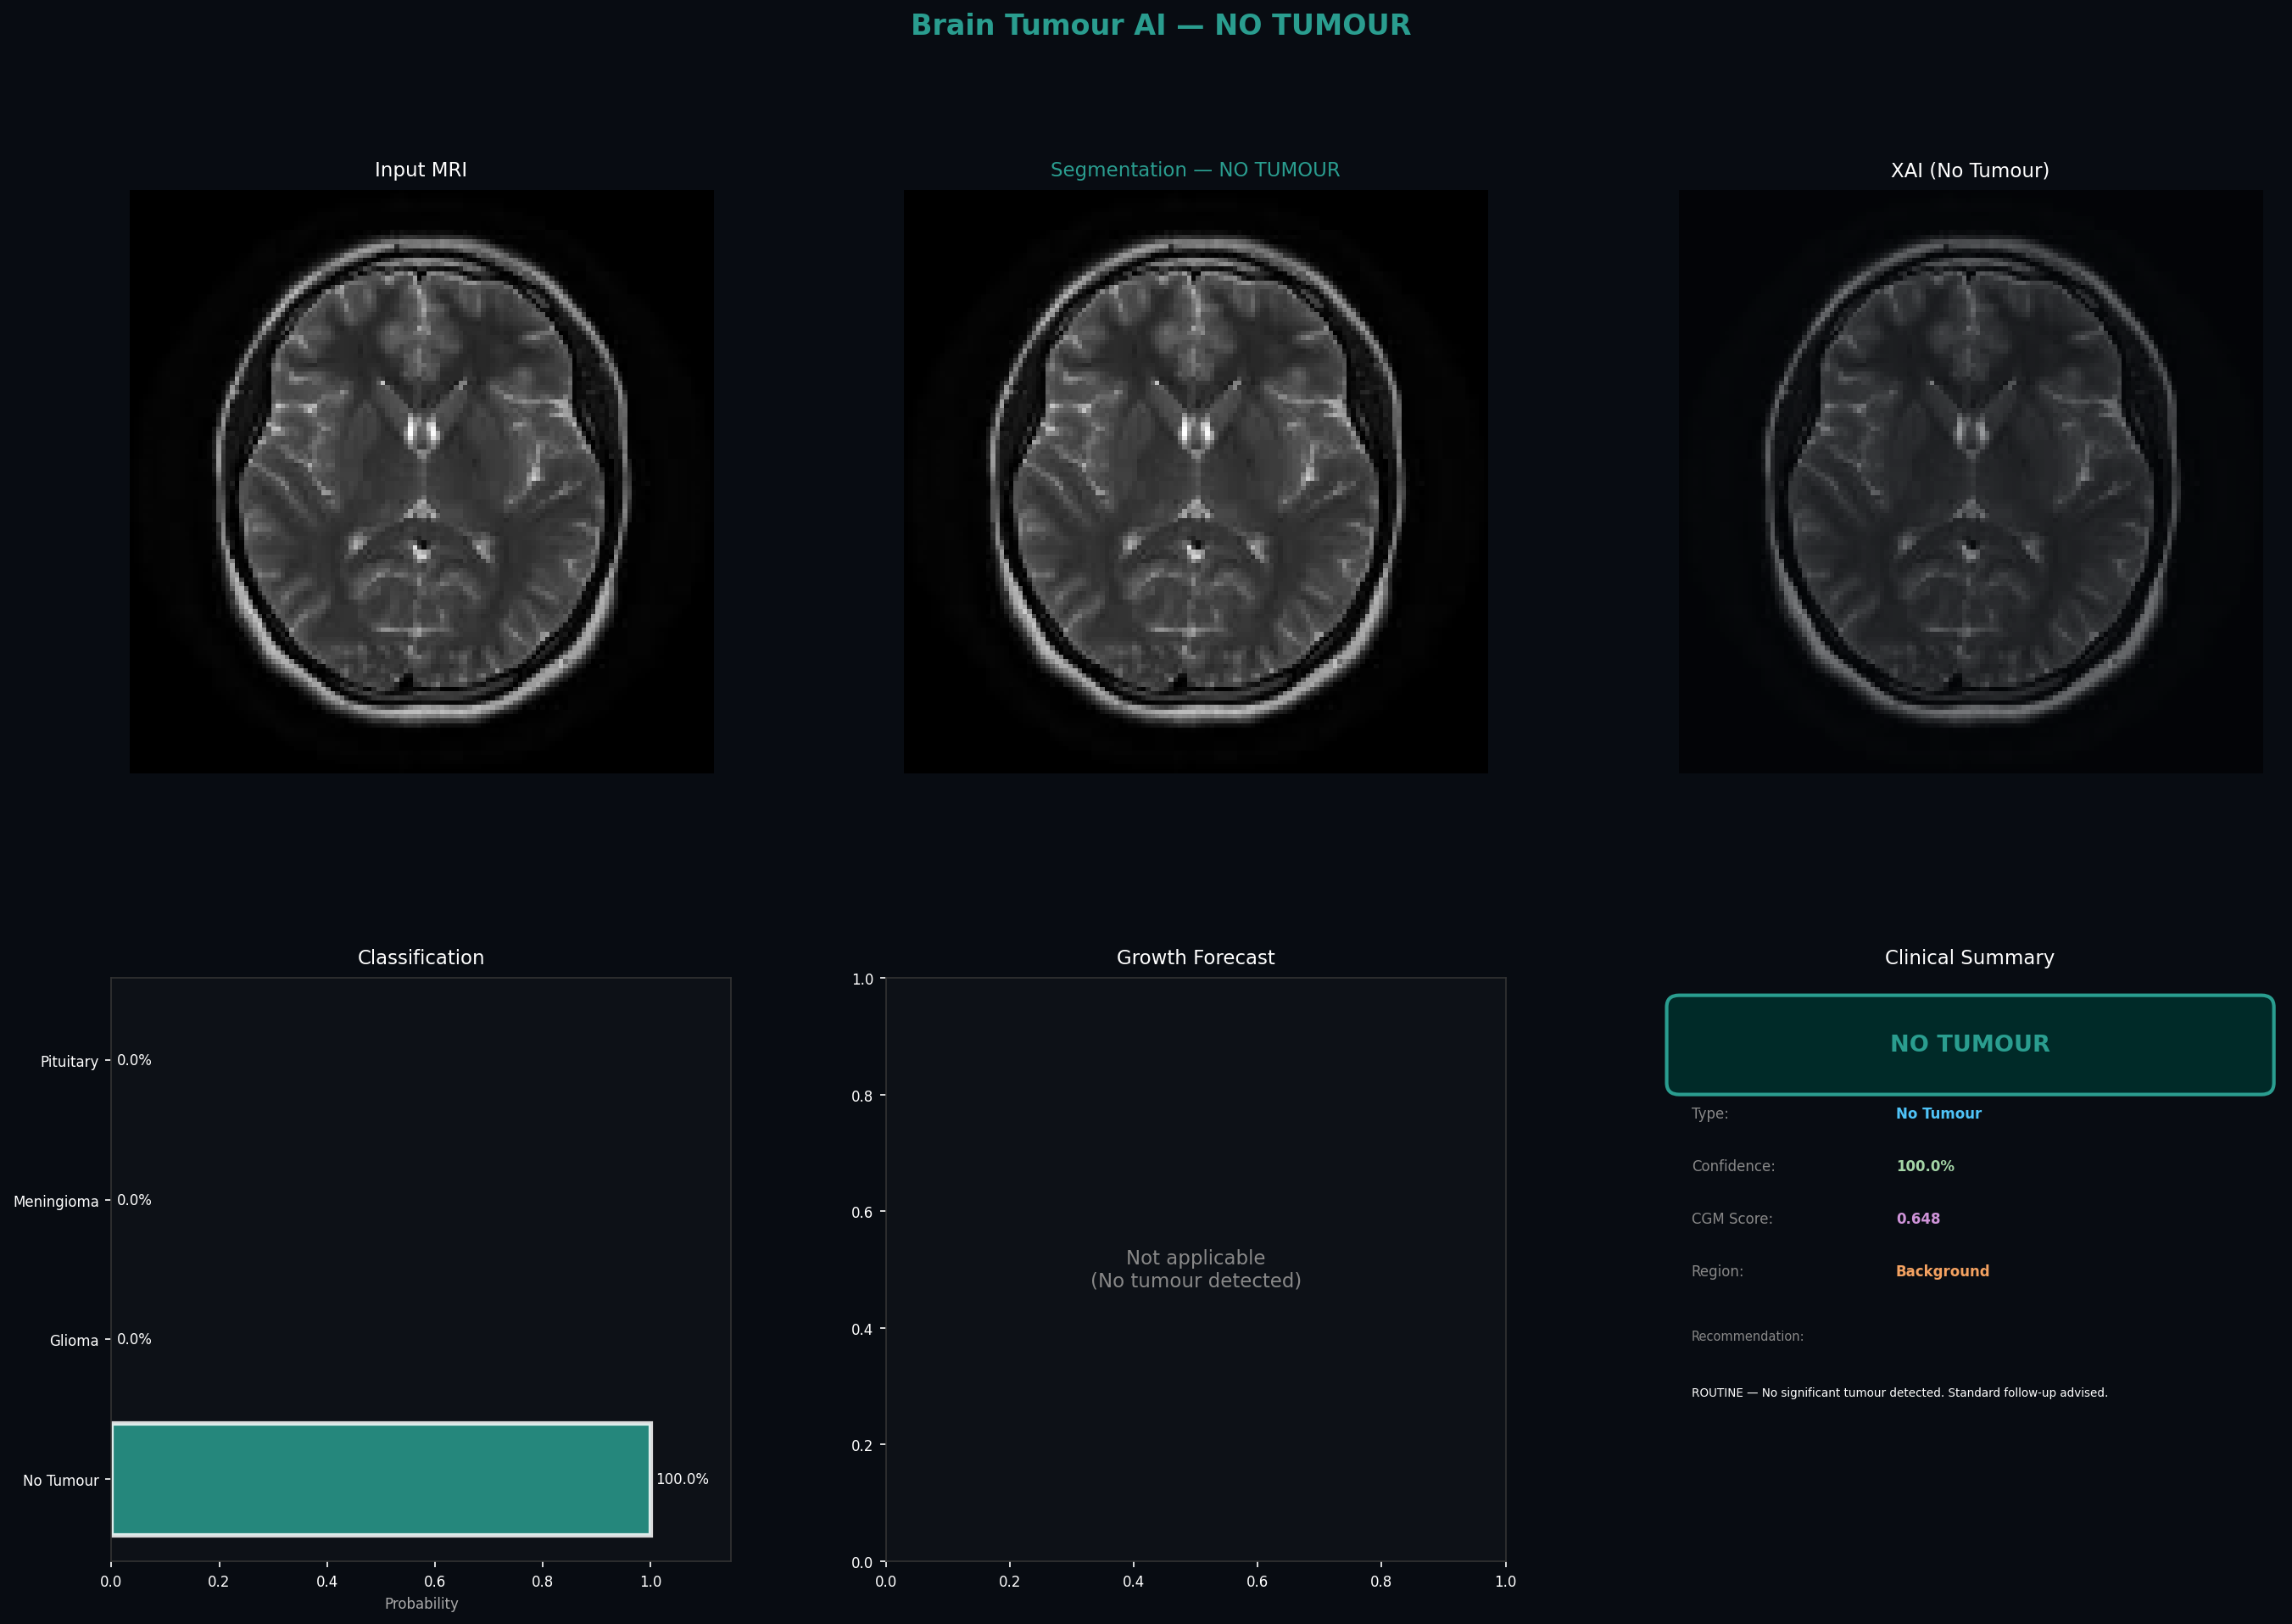

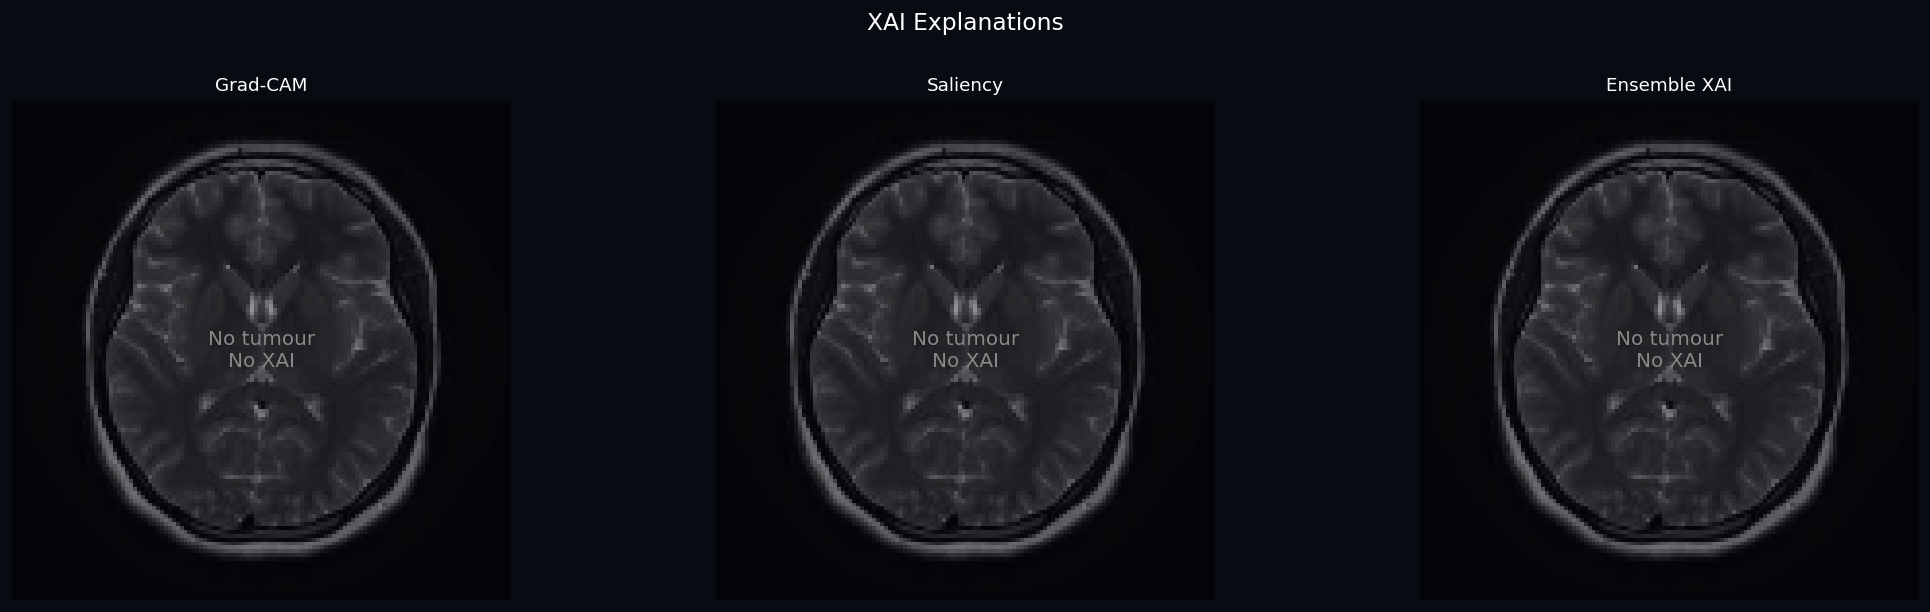

JSON saved: outputs/clinical_report.json

  FINAL RESULT: NO TUMOUR
  Type         : No Tumour
  Confidence   : 100.0%
  Recommend    : ROUTINE — No significant tumour detected. Standard follow-up advised.


In [ ]:
import cv2, numpy as np, torch
from google.colab import files

# Load all 4 models (reuse already loaded ones or reload)
# seg_model, cls_model, surv_model, grow_model must be in scope

orchestrator = BrainTumourOrchestrator(
    seg_model  = seg_model,
    cls_model  = cls_model,
    surv_model = surv_model,
    grow_model = grow_model,
    device     = "cuda",
    seg_thresh = 0.45,
)

print("Upload your MRI image:")
uploaded = files.upload()
img_name = list(uploaded.keys())[0]

img_bgr  = cv2.imread(img_name)
img_gray = cv2.imread(img_name, cv2.IMREAD_GRAYSCALE)
if img_bgr is not None and len(img_bgr.shape)==3:
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

img = cv2.resize(img_gray,(128,128)).astype(np.float32)
img = (img-img.min())/(img.max()-img.min()+1e-8)

tensor = torch.from_numpy(
    np.stack([img]*4,axis=0)).float().unsqueeze(0)

result = orchestrator.predict(
    tensor,
    patient_id     = "PATIENT_001",
    patient_name   = "Test Patient",
    patient_age    = "45",
    patient_gender = "M",
    save_dir       = "outputs",
)

In [ ]:
!pip install fpdf

import fpdf # Import fpdf directly
from fpdf import FPDF
import time, os
from IPython.display import display, Image as IPImage
from google.colab import files

def generate_doctor_pdf(r, save_dir="outputs"):
    TUMOUR_TYPES = {0:"No Tumour",1:"Glioma",2:"Meningioma",3:"Pituitary"}

    pdf = FPDF()
    pdf.set_auto_page_break(auto=True, margin=15)

    # ── Page 1 ────────────────────────────────────────────────
    pdf.add_page()
    pdf.set_margins(15,15,15)

    # Header
    pdf.set_fill_color(8,12,18)
    pdf.rect(0,0,210,32,"F")
    pdf.set_text_color(255,255,255)
    pdf.set_font("Helvetica","B",17)
    pdf.set_xy(15,7)
    pdf.cell(180,9,"BRAIN TUMOUR AI DIAGNOSTIC REPORT",ln=True)
    pdf.set_font("Helvetica","",9)
    pdf.set_xy(15,18)
    pdf.cell(180,6,f"Generated: {r['timestamp']}   |   "
                   f"Patient: {r['patient_id']}",ln=True)
    pdf.set_text_color(0,0,0)

    # Patient info box
    pdf.set_y(37)
    pdf.set_fill_color(235,240,255)
    pdf.rect(15,37,180,26,"F")
    pdf.set_font("Helvetica","B",10)
    pdf.set_xy(18,39)
    pdf.cell(180,6,"PATIENT INFORMATION",ln=True)
    pdf.set_font("Helvetica","",10)
    pdf.set_xy(18,46)
    pdf.cell(55,5,f"ID     : {r['patient_id']}")
    pdf.cell(60,5,f"Name   : {r['patient_name']}")
    pdf.cell(60,5,f"Age    : {r['patient_age']}",ln=True)
    pdf.set_xy(18,52)
    pdf.cell(55,5,f"Gender : {r['patient_gender']}")
    pdf.cell(120,5,f"Date   : {r['timestamp']}")

    # Detection result
    pdf.set_y(67)
    det_col = (210,45,45) if r["has_tumour"] else (42,157,143)
    pdf.set_fill_color(*det_col)
    pdf.set_text_color(255,255,255)
    pdf.set_font("Helvetica","B",15)
    pdf.rect(15,67,180,13,"F")
    pdf.set_xy(15,69)
    label = "TUMOUR DETECTED" if r["has_tumour"] else "NO TUMOUR DETECTED"
    pdf.cell(180,9,label,align="C",ln=True)
    pdf.set_text_color(0,0,0)

    # Classification results
    pdf.set_y(84)
    pdf.set_fill_color(200,215,235)
    y = pdf.get_y()
    pdf.rect(15,y,180,8,"F")
    pdf.set_font("Helvetica","B",11)
    pdf.set_xy(15,y)
    pdf.cell(180,8,"CLASSIFICATION RESULTS",ln=True)
    pdf.set_font("Helvetica","",10)

    rows = [
        ("Tumour Type",    r["type_name"]),
        ("Confidence",     f"{r['confidence']*100:.1f}%"),
        ("CGM Score",      f"{r['cgm_confidence']:.4f}"),
        ("Tumour Pixels",  str(r["tumour_pixels"])),
        ("Dominant Region",r["dominant_region"]),
        ("Uncertain Flag", ("YES - Expert review needed"
                           if r["is_uncertain"] else "NO")),
        ("Conflict",       ("Segmentor overrode classifier"
                           if r["conflict"] else "None")),
    ]
    for i,(k,v) in enumerate(rows):
        if i%2==0: pdf.set_fill_color(245,248,255)
        else:      pdf.set_fill_color(255,255,255)
        pdf.set_x(15)
        pdf.set_font("Helvetica","B",10); pdf.cell(65,7,f"{k}:",fill=True)
        pdf.set_font("Helvetica","",10);  pdf.cell(115,7,v,fill=True,ln=True)

    # Type probabilities
    pdf.set_y(pdf.get_y()+3)
    pdf.set_font("Helvetica","B",10)
    pdf.set_x(15); pdf.cell(180,6,"Tumour Type Probabilities:",ln=True)
    pdf.set_font("Helvetica","",10)
    for i in range(4):
        pdf.set_x(22)
        pdf.cell(80,6,f"{TUMOUR_TYPES[i]}:")
        pdf.cell(40,6,f"{r['type_probs'][i]*100:.1f}%",ln=True)

    # Survival section
    pdf.set_y(pdf.get_y()+4)
    y = pdf.get_y()
    pdf.set_fill_color(200,215,235)
    pdf.rect(15,y,180,8,"F")
    pdf.set_font("Helvetica","B",11)
    pdf.set_xy(15,y); pdf.cell(180,8,"SURVIVAL ESTIMATE",ln=True)
    pdf.set_font("Helvetica","",10)
    if r["survival_days"]:
        pdf.set_x(15)
        pdf.cell(70,7,"Estimated Survival:")
        pdf.cell(110,7,f"{r['survival_days']:.0f} days  "
                        f"({r['survival_days']/365:.1f} years)",ln=True)
        pdf.set_x(15)
        pdf.cell(70,7,"Prognosis:")
        pdf.cell(110,7,r["survival_interp"].replace("—", " - "),ln=True) # Replace em dash
    else:
        pdf.set_x(15)
        pdf.cell(180,7,r["survival_interp"].replace("—", " - "),ln=True) # Replace em dash

    # Growth forecast section
    pdf.set_y(pdf.get_y()+4)
    y = pdf.get_y()
    pdf.set_fill_color(200,215,235)
    pdf.rect(15,y,180,8,"F")
    pdf.set_font("Helvetica","B",11)
    pdf.set_xy(15,y); pdf.cell(180,8,"GROWTH FORECAST",ln=True)

    if r["growth_forecast"]:
        pdf.set_font("Helvetica","B",10)
        pdf.set_fill_color(180,200,220)
        for h in ["Timepoint","Est. Voxels","Change %","Trend"]:
            pdf.cell(45,7,h,border=1,fill=True,align="C")
        pdf.ln()
        pdf.set_font("Helvetica","",10)
        for f in r["growth_forecast"]:
            for val in [f" +{f['days']} days",
                        f"{f['vox']:,} \u00b1 {f['std']:,}",
                        f"{f['pct']:.1f}%",
                        f["trend"]]:
                pdf.cell(45,7,str(val),border=1,align="C")
            pdf.ln()
    else:
        pdf.set_font("Helvetica","",10)
        pdf.set_x(15)
        pdf.cell(180,7,"Not applicable - no tumour detected or uncertain classification",ln=True) # Replaced em dash

    # Recommendation box
    pdf.set_y(pdf.get_y()+5)
    y = pdf.get_y()
    rec_fill = (255,235,235) if r["has_tumour"] else (235,255,245)
    pdf.set_fill_color(*rec_fill)
    pdf.rect(15,y,180,8,"F")
    pdf.set_font("Helvetica","B",11)
    pdf.set_xy(15,y); pdf.cell(180,8,"CLINICAL RECOMMENDATION",ln=True)
    pdf.set_font("Helvetica","",10)
    pdf.set_x(15)
    pdf.multi_cell(180,6,r["recommendation"].replace("—", " - ")) # Replace em dash

    # ── Page 2: Images ────────────────────────────────────────
    pdf.add_page()
    pdf.set_font("Helvetica","B",12)
    pdf.set_fill_color(8,12,18)
    pdf.set_text_color(255,255,255)
    pdf.rect(0,0,210,18,"F")
    pdf.set_xy(15,5)
    pdf.cell(180,8,"IMAGING ANALYSIS",ln=True)
    pdf.set_text_color(0,0,0)
    pdf.set_y(22)

    try:
        pdf.image("outputs/diagnostic_report.png",
                  x=10, y=22, w=190)
        pdf.set_y(22+130)
    except Exception as e:
        print(f"Diagnostic image embed skipped: {e}")

    try:
        pdf.image("outputs/xai_explanations.png",
                  x=10, y=pdf.get_y()+5, w=190)
    except Exception as e:
        print(f"XAI image embed skipped: {e}")

    # ── Page 3: Radiomics ─────────────────────────────────────
    pdf.add_page()
    pdf.set_font("Helvetica","B",12)
    pdf.set_fill_color(8,12,18)
    pdf.set_text_color(255,255,255)
    pdf.rect(0,0,210,18,"F")
    pdf.set_xy(15,5)
    pdf.cell(180,8,"QUANTITATIVE RADIOMICS (20 Features)",ln=True)
    pdf.set_text_color(0,0,0)
    pdf.set_y(22)

    rad_names = [
        "shape_area","shape_perimeter","shape_compactness",
        "shape_eccentricity","shape_extent","shape_solidity",
        "int_mean","int_std","int_skew","int_kurt",
        "int_p10","int_p25","int_p75","int_p90",
        "glcm_contrast","glcm_homogeneity","glcm_energy",
        "glcm_entropy","glcm_correlation","glcm_variance",
    ]
    rad_vals = r["radiomics"]
    pdf.set_font("Helvetica","B",10)
    pdf.set_fill_color(180,200,220)
    pdf.cell(95,7,"Feature",border=1,fill=True,align="C")
    pdf.cell(95,7,"Value",  border=1,fill=True,align="C")
    pdf.ln()
    pdf.set_font("Helvetica","",9)
    for i,(name,val) in enumerate(zip(rad_names,rad_vals)):
        if i%2==0: pdf.set_fill_color(245,248,255)
        else:      pdf.set_fill_color(255,255,255)
        pdf.cell(95,6,name,border=1,fill=True)
        pdf.cell(95,6,f"{float(val):.6f}",border=1,fill=True,align="R")
        pdf.ln()

    # ── Page 4: Disclaimer ────────────────────────────────────
    pdf.add_page()
    pdf.set_fill_color(255,235,235)
    pdf.rect(15,15,180,80,"F")
    pdf.set_xy(15,18)
    pdf.set_font("Helvetica","B",12)
    pdf.cell(180,8,"IMPORTANT MEDICAL DISCLAIMER",ln=True)
    pdf.set_xy(15,28)
    pdf.set_font("Helvetica","",9)
    pdf.set_text_color(150,0,0)
    pdf.multi_cell(180,6,
        "This report is generated by an AI system for RESEARCH AND "
        "EDUCATIONAL PURPOSES ONLY. It has NOT been clinically validated "
        "and must NOT be used as the sole basis for any medical decision. "
        "All findings must be reviewed and confirmed by a qualified "
        "radiologist or neurosurgeon before any clinical action is taken. "
        "Survival and growth estimates are based on population statistics "
        "and synthetic training data - they are NOT patient-specific "
        "clinical prognoses. AI predictions may be incorrect. "
        "The developers accept no liability for clinical outcomes based "
        "on this report.") # Replaced em dash
    pdf.set_text_color(0,0,0)

    # Footer on last page
    pdf.set_y(260)
    pdf.set_font("Helvetica","I",8)
    pdf.set_text_color(120,120,120)
    pdf.cell(180,5,
        f"Brain Tumour AI v2.0  |  {r['timestamp']}  |  {r['patient_id']}",
        align="C")

    # Save and download
    pdf_path = f"{save_dir}/doctor_report.pdf"
    pdf.output(pdf_path)
    size = os.path.getsize(pdf_path)/1024
    print(f"PDF saved: {pdf_path}  ({size:.0f} KB)")
    files.download(pdf_path)
    print("PDF downloaded to your PC")

# Run it
generate_doctor_pdf(result, save_dir="outputs")

PDF saved: outputs/doctor_report.pdf  (317 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PDF downloaded to your PC
